# Experiment: COMP 484/584 Homework 2 (Problem 3)

Objective:
- Implement an LSTM language model from scratch (no `torch.nn.LSTM` / `torch.nn.LSTMCell`).
- Train on a synthetic copy task and report required metrics.

Success criteria:
- Clean convergence on the copy task.
- Final perplexity close to 1.
- Plot training loss and cell-state gradient norm over time.

In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. LSTM Cell From Scratch

We implement all four gates directly from the graph equations:
- forget gate `f_t`
- input gate `i_t`
- output gate `o_t`
- candidate state `g_t`

In [2]:
class LSTMCellScratch(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size

        concat_size = input_size + hidden_size
        self.forget_linear = nn.Linear(concat_size, hidden_size)
        self.input_linear = nn.Linear(concat_size, hidden_size)
        self.output_linear = nn.Linear(concat_size, hidden_size)
        self.candidate_linear = nn.Linear(concat_size, hidden_size)

    def forward(self, x_t: torch.Tensor, h_prev: torch.Tensor, c_prev: torch.Tensor):
        combined = torch.cat([h_prev, x_t], dim=1)

        f_t = torch.sigmoid(self.forget_linear(combined))
        i_t = torch.sigmoid(self.input_linear(combined))
        o_t = torch.sigmoid(self.output_linear(combined))
        g_t = torch.tanh(self.candidate_linear(combined))

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

## 2. Sequence Language Model

Model components:
- Embedding layer
- Custom `LSTMCellScratch`
- Linear output layer to vocabulary logits

The forward pass returns logits at every time step.

In [3]:
class LSTMLanguageModelScratch(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.cell = LSTMCellScratch(embedding_dim, hidden_size)
        self.output_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, tokens: torch.Tensor, return_c_states: bool = False):
        batch_size, seq_len = tokens.shape
        embeddings = self.embedding(tokens)

        h_t = torch.zeros(batch_size, self.hidden_size, device=tokens.device)
        c_t = torch.zeros(batch_size, self.hidden_size, device=tokens.device)

        logits = []
        c_states = []

        for t in range(seq_len):
            x_t = embeddings[:, t, :]
            h_t, c_t = self.cell(x_t, h_t, c_t)
            if return_c_states:
                c_t.retain_grad()
                c_states.append(c_t)
            logits.append(self.output_layer(h_t).unsqueeze(1))

        logits = torch.cat(logits, dim=1)
        if return_c_states:
            return logits, c_states
        return logits

## 3. Copy Task Data and Training Utilities

Synthetic task:
- Input: `x_1, ..., x_T`
- Target: `x_1, ..., x_T`

In [4]:
def sample_copy_batch(batch_size: int, seq_len: int, vocab_size: int, device: torch.device):
    # Sample uniformly from the full vocabulary: token IDs 0..V-1.
    x = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len), device=device)
    y = x.clone()
    return x, y


def evaluate_model(
    model: nn.Module,
    eval_batches: int,
    batch_size: int,
    seq_len: int,
    vocab_size: int,
    device: torch.device,
):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for _ in range(eval_batches):
            x, y = sample_copy_batch(batch_size, seq_len, vocab_size, device)
            logits = model(x)
            loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            total_correct += (preds == y).sum().item()
            total_tokens += y.numel()

    avg_loss = total_loss / eval_batches
    perplexity = math.exp(avg_loss)
    accuracy = total_correct / total_tokens
    return avg_loss, perplexity, accuracy

## 4. Train the Scratch LSTM Model

In [5]:
# Hyperparameters
VOCAB_SIZE = 30
EMBED_DIM = 32
HIDDEN_SIZE = 64
SEQ_LEN = 30
BATCH_SIZE = 128
EPOCHS = 20
STEPS_PER_EPOCH = 60
LEARNING_RATE = 3e-3

model = LSTMLanguageModelScratch(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for _ in range(STEPS_PER_EPOCH):
        x, y = sample_copy_batch(BATCH_SIZE, SEQ_LEN, VOCAB_SIZE, DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / STEPS_PER_EPOCH
    train_losses.append(avg_train_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | loss={avg_train_loss:.6f} | "
            f"perplexity={math.exp(avg_train_loss):.6f}"
        )

val_loss, val_ppl, val_acc = evaluate_model(
    model=model,
    eval_batches=30,
    batch_size=128,
    seq_len=SEQ_LEN,
    vocab_size=VOCAB_SIZE,
    device=DEVICE,
)

print(f"\nFinal validation loss: {val_loss:.8f}")
print(f"Final validation perplexity: {val_ppl:.8f}")
print(f"Final validation token accuracy: {val_acc:.4f}")


Epoch 01 | loss=1.547854 | perplexity=4.701371


Epoch 05 | loss=0.004344 | perplexity=1.004353


Epoch 10 | loss=0.001128 | perplexity=1.001128


Epoch 15 | loss=0.000530 | perplexity=1.000530


Epoch 20 | loss=0.000310 | perplexity=1.000310

Final validation loss: 0.00029591
Final validation perplexity: 1.00029595
Final validation token accuracy: 1.0000


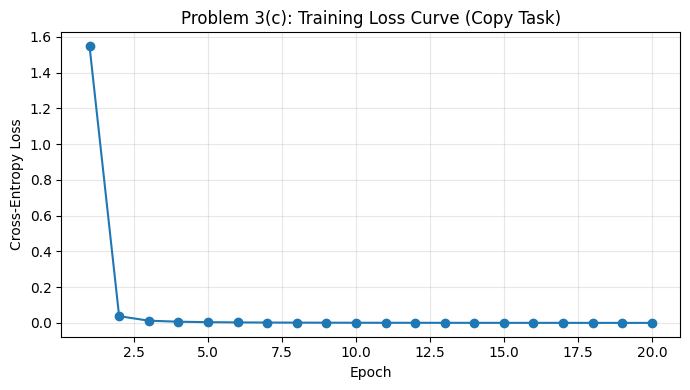

Saved: /Users/apple/Coded/Rice/NLP/HW2/figures/problem3_loss_curve.png


In [6]:
# Plot training loss curve
fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3(c): Training Loss Curve (Copy Task)")
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = fig_dir / "problem3_loss_curve.png"
plt.savefig(loss_plot_path, dpi=180)
plt.show()

print(f"Saved: {loss_plot_path.resolve()}")

## 5. Gradient Norm of Cell State Over Time

We backpropagate one sequence loss and record `||∂J/∂c_t||_2` for each time step.

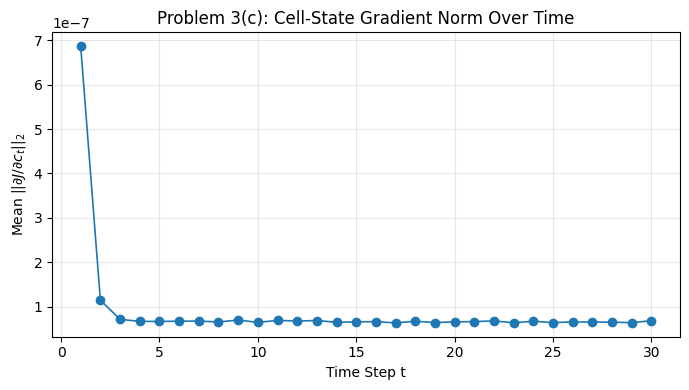

Saved: /Users/apple/Coded/Rice/NLP/HW2/figures/problem3_cell_grad_norm.png
Min gradient norm: 0.0000000631
Max gradient norm: 0.0000006867


In [7]:
model.eval()
model.zero_grad(set_to_none=True)

x_probe, y_probe = sample_copy_batch(BATCH_SIZE, SEQ_LEN, VOCAB_SIZE, DEVICE)
probe_logits, c_states = model(x_probe, return_c_states=True)
probe_loss = F.cross_entropy(probe_logits.reshape(-1, VOCAB_SIZE), y_probe.reshape(-1))
probe_loss.backward()

cell_grad_norms = [c.grad.norm(dim=1).mean().item() for c in c_states]

plt.figure(figsize=(7, 4))
plt.plot(range(1, SEQ_LEN + 1), cell_grad_norms, marker="o", linewidth=1.2)
plt.xlabel("Time Step t")
plt.ylabel(r"Mean $||\partial J / \partial c_t||_2$")
plt.title("Problem 3(c): Cell-State Gradient Norm Over Time")
plt.grid(alpha=0.3)
plt.tight_layout()

grad_plot_path = fig_dir / "problem3_cell_grad_norm.png"
plt.savefig(grad_plot_path, dpi=180)
plt.show()

print(f"Saved: {grad_plot_path.resolve()}")
print(f"Min gradient norm: {min(cell_grad_norms):.10f}")
print(f"Max gradient norm: {max(cell_grad_norms):.10f}")

## Deliverables Summary

This notebook provides the coding components required by Problem 3:
- `LSTMCellScratch` implementation
- sequence language model using the custom cell
- copy-task training run
- training loss curve, final perplexity, and cell-state gradient-norm plot